# Finding Roots

**Problems to solve:**
For a given function $f(x)$, we want to find $x$ values (roots) that satisfy $f(x) = 0$. When possible, it is helpful to first plot $f(x)$ versus $x$ to estimate the roots.

In [1]:
# Import numpy ans matplotlib for calculation and visualization:
import numpy as np
import matplotlib.pyplot as plt

## Iteration (or Relaxation) Method
Given $f(x)$, if we can re-write it as $f(x) = g(x)-x$, then the root-finding problem becomes $f(x) = g(x) -x = 0$, or $x = g(x)$. The solution is also called the fixed point $x^*$, which satisfies $x^* = g(x^*)$.

For an initial guess of the solution $x_0$, one obtains the next iterative solution $x_1 = g(x_0)$, then $x_2 = g(x_1)$, then $x_3 = g(x_2)$, and so forth, until the required accuracy is reached. Hopefully, the iterative result will converge to the exact solution. 

**Example.** Find the roots of $f(x) = e^{x-\sqrt{x}}-x = 0$.

**Sol:** We re-write it as $f(x) = g(x) - x = 0$, or $x = e^{x-\sqrt{x}} = g(x)$, then use the iterative method to find the fix point $x^* = g(x^*)$.

In [2]:
from math import exp, sqrt

def g(x):
    return exp(x-sqrt(x))

In [7]:
# fixed point iteration method:
def fixedpoint(g, xold, kmax=100, tol=1.0e-10):
    
    for k in range(1,kmax+1):
        xnew = g(xold)
            
        if abs(xnew - xold) < tol: break
            
        xold = xnew
                
    #The following 4 lines can be commented out.
    if(k == kmax):
        print('max iteration reached.')
    else:
        print(k, 'iterations to reach accuracy.')

    return xnew

In [10]:
xfixed = fixedpoint(g, 0.9)

print(xfixed)
print(g(xfixed)-xfixed)
#Note: one of the exact roots is 1.0.

30 iterations to reach accuracy.
0.9999999999155589
4.2220560381167616e-11


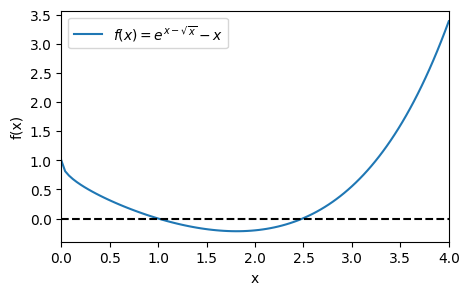

In [11]:
# Plot f(x) [NOT g(x)!] versus x to estimate the roots.
a=0
b=4
n=101

x = np.linspace(a,b,n)
f = np.exp(x - np.sqrt(x)) - x

fig, ax = plt.subplots(figsize=(5,3))

#Note the use of raw string, by putting "r" in front of '...'.
#Alternatively, one can use two slashes in the latex symbol $...$.
ax.plot(x,f, label=r'$f(x) = e^{x-\sqrt{x}}-x$')
ax.axhline(y=0,ls='--',c='k')

ax.set_xlim(a,b)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()

# The roots are around x = 1 and x = 2.5.

**Note:** The fixed point iteration works only when $|g'(x^*)| \le 1$.

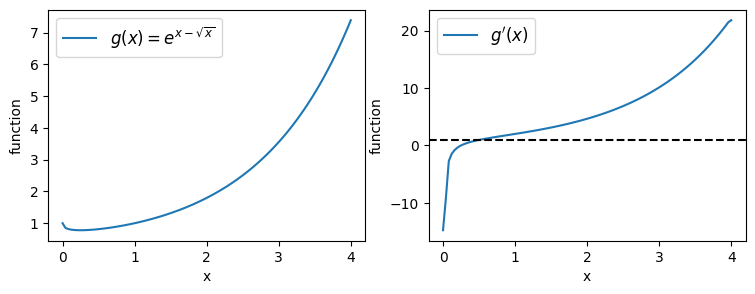

In [12]:
# plot g(x) and g'(x):

fig, axes = plt.subplots(1,2,figsize=(9,3))

a=0
b=4
n=101
# step size delta_x = (b-a)/(n-1) = 0.04

x = np.linspace(a,b,n)
g = np.exp(x - np.sqrt(x))

# Finite difference size h (which need NOT be the same as delta_x):
h=0.01

# Use numpy built-in function np.gradient to evaluate the derivative:
gprime = np.gradient(g, h)
#The gradient is using second-order accurate central differences.
#The returned gradient has the same shape as the input array.
#The spacing can be specified using various ways; check documents.

axes[0].plot(x,g,label=r'$g(x) = e^{x-\sqrt{x}}$')
axes[0].set_xlabel('x')
axes[0].set_ylabel('function')
axes[0].legend(fontsize=12)

axes[1].plot(x,gprime,label="$g'(x)$")
axes[1].set_xlabel('x')
axes[1].set_ylabel('function')
axes[1].legend(fontsize=12)
axes[1].axhline(y=1,c='k',ls='--')

If we take natural log on both sides of $e^{x-\sqrt{x}} = x$ to get $x-\sqrt{x}=\ln x$, this leads to $x = \ln(x) + \sqrt{x} \equiv g(x)$. In this case, $|g'(x)| \le 1$ at the larger root.

In [13]:
from math import log, sqrt

def g(x):
    return log(x) + sqrt(x)

In [15]:
xfixed = fixedpoint(g, 2)

print(xfixed)
print(g(xfixed)-xfixed)

66 iterations to reach accuracy.
2.490909316722599
6.293587873074102e-11


## Bisection Method
The goal is to solve $f(x) = 0$.

The bisection method **always works**, and its algorithm proceeds as follows:

1. Find an initial interval ($x_0$, $x_1$), such that f(x) has opposite signs in the two end points, i.e., $f(x_0)f(x_1)<0$.
2. Define $x_2\equiv (x_0+x_1)/2$.
3. If $f(x_0)f(x_2)<0$, the solution is in the interval $(x_0,x_2)$, so let $x_1\equiv x_2$. Otherwise, if $f(x_0)f(x_2) > 0$, the solution is in the interval $(x_2,x_1)$, so let $x_0\equiv x_2$.

4. Repeat the above steps 2 and 3 for a fixed number of $k_{max}$ iterations. At the $k_{th}$ step, for $x^{(k)}\equiv x_2$, $|x^{(k)}-x^*| \le \frac{b-a}{2^{k+1}}$, where $(a,b)$ is the initial interval $(x_0, x_1)$.

In [16]:
# bisection method:
def bisection(f, x0, x1, kmax = 100):

    f0=f(x0)
    f1=f(x1)
        
    if (f0*f1>0):
        print('f0*f1 should be less than 0.')
        return None
    
    if (f0*f1==0):
        print('The initial x0 or x1 is the solution.')
        return None
    
    for k in range(1,kmax+1):

        x2=(x0+x1)/2
        
        #The following line can be commented:
        #print(k, x2)

        f0=f(x0); f1=f(x1); f2=f(x2)
        
        if (f0*f2) < 0:
            x1 = x2
        else:
            x0 = x2

        if (f0*f2 == 0):
            break
                        
    return x2

In [17]:
# define the funciton f(x):
from math import exp, sqrt

def f(x):
    return exp(x-sqrt(x))-x

In [18]:
root1 = bisection(f, 0.8, 1.5)
root2 = bisection(f, 2, 3)

print(root1)
print(root2)

1.0000000000000002
2.4909093169459853


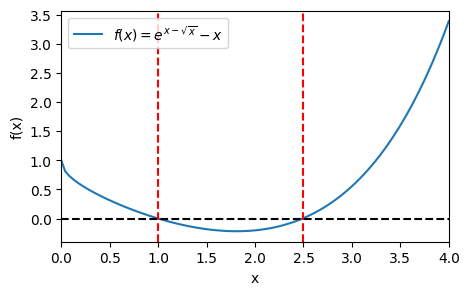

In [19]:
# plot f(x) versus x:

a=0
b=4
n=101

x = np.linspace(a,b,n)
f = np.exp(x - np.sqrt(x)) - x

fig, ax = plt.subplots(figsize=(5,3))

ax.plot(x,f, label=r'$f(x) = e^{x-\sqrt{x}}-x$')
ax.axhline(y=0,ls='--',c='k')

ax.set_xlim(a,b)

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.legend()

# indicate the root locations:
ax.axvline(x=root1, c='r', linestyle='--')
ax.axvline(x=root2, c='r', linestyle='--')

## Newton's Method
The goal is to solve $f(x) = 0$.

For an initial guess of $x_0$, the algorithm proceeds as 
\begin{equation}
x_k = x_{k-1} - \frac{f(x_{k-1})}{f'(x_{k-1})}; \, k = 1,2,3, ...
\end{equation}

The method can converge fastly, but one needs to evaluate additionally the first derivative of $f(x)$.

## Secant Method
The goal is to solve $f(x) = 0$.

For two initial guesses $x_0$ and $x_1$, the algorithm proceeds as 
\begin{equation}
x_k = x_{k-1} - f(x_{k-1})\frac{x_{k-1}-x_{k-2}}{f(x_{k-1})-f(x_{k-2})}; k = 2,3, ...
\end{equation}

This method is similar to the Newton's method, but it replaces the evaluation of first derivative by a finite difference.

**Example.** Find the roots of $f(x) = e^{x-\sqrt{x}}-x = 0$, by using the secant method.

In [20]:
# define the funciton f(x):
from math import exp, sqrt

def f(x):
    return exp(x-sqrt(x))-x

In [21]:
# secant method:
def secant(f, x0, x1, kmax= 100, tol=1.0e-10):
    
    for k in range(1,kmax+1):
        f0 = f(x0)
        f1 = f(x1)
        ratio = (x1-x0)/(f1-f0)
        x2 = x1 - f1*ratio
        
        #The following line can be commented:
        #print(k, x2)

        xdiff = abs(x2-x1)
        
        if(xdiff <= tol):
            break
        
        x0 = x1
        x1 = x2
        
    #The following 4 lines can be commented out.
    if(k == kmax):
        print('max iteration reached.')
    else:
        print(k, 'iterations to reach accuracy.')    
        
    return x2

In [22]:
root = secant(f,2.6, 2.8)
print('root:', root)

root = secant(f,2.1,2)
print('root:', root)

6 iterations to reach accuracy.
root: 2.4909093169459853
9 iterations to reach accuracy.
root: 2.490909316945985


In [23]:
secant(f,0.7,0.8)

6 iterations to reach accuracy.


1.0

<b>Note:</b> Inspired by Newton's method, we want to choose initial guesses $x_0$ not too different from $x_1$.

Also, in this problem, $f(x)$ is well-defined only for $x\ge 0$ (due to $\sqrt{x}$). Therefore, for the secant method, one needs to choose the initial guesses $x_0$ and $x_1$ carefully, to avoid obtaining a negative $x_k$ during the iteration.

## Minimization (or Optimization) of $\phi(\mathbf{x})$

The extreme values of $\phi(\mathbf{x})$ occur at $\nabla\phi(\mathbf{x^*})=0$. To find $\mathbf{x^*}$, we can use the (iterative) gradient descent method, where at the $k$-the iteration, $\mathbf{x}^{(k)} = \mathbf{x}^{(k-1)} - \alpha \nabla \phi(\mathbf{x}^{(k-1)})$. Here, the learning rate $\alpha$ should be a small, positive number (e.g. 0.1, 0.01, or smaller) to ensure a proper convergence.

**Example.** The function $\phi(x_0,x_1) = x_0^2-2x_0+x_1^4-2x_1^2+x_1$ depends on two independent variables $x_0$, and $x_1$. Visualize $\phi(x_1,x_2)$ and locate their minima by the gradient descent method.


In [ ]:
# Import numpy ans matplotlib for calculation and visualization:
import numpy as np
import matplotlib.pyplot as plt

# Importing the colormap module:
import matplotlib.cm as cm

In [ ]:
# Visualize the function:
x0 = np.linspace(-2, 2)
x1 = np.linspace(-2, 2)

X0,X1 = np.meshgrid(x0,x1)
PHI = X0**2-2*X0+X1**4-2*X1**2+X1

fig, ax = plt.subplots()
ax.set_xlabel('x_0')
ax.set_ylabel('x_1')

im = ax.imshow(PHI, cmap=cm.hot, extent=(-2,2,-2,2))
fig.colorbar(im, ax = ax)

levels=list(np.arange(-3,9,1))
ct = ax.contour(X0,X1,PHI, levels, cmap=cm.bwr)
ax.clabel(ct, fmt='%d')

In [ ]:
# Gradient descent method:

def phi(x):
    x0, x1 = x
    return x0**2-2*x0+x1**4-2*x1**2+x1

def gradient(phi, x, h=1e-4):
    n = x.size
    phi0 = phi(x)
    
    grad=np.zeros(n)
    
    for ii in range(n):
        #create an independent copy:
        xnew = 1.0*x
        
        xnew[ii] = xnew[ii] + h 
        grad[ii] = (phi(xnew) - phi(x))/h
    
    return grad

#Note: alpha can crucially affect the result and need to be tested.
#If alpha is too large, the result won't converge!
def descent(phi, gradient, xold, alpha=0.1, kmax=200, tol=1e-8):

    path=[xold]
    
    for k in range(1,kmax+1):

        xnew = xold - alpha*gradient(phi, xold)
        path.append(xnew)
        
        err = abs(phi(xnew)-phi(xold))
        #err = np.linalg.norm(xnew-xold)
        
        #print(k, xnew, err, phi(xnew))
        
        if err < tol: break

        #create an independent copy:        
        xold = 1.0*xnew

    print(k, xnew, err, phi(xnew))
    
    return np.array(path)

In [ ]:
xold =np.array([-2,2])
path1 = descent(phi, gradient, xold)

xold = np.array([0, 2])
path2 = descent(phi, gradient, xold)

xold = np.array([1.5, 1.5])
path3 = descent(phi, gradient, xold)

In [ ]:
# Visualize the function:
x0 = np.linspace(-2, 2)
x1 = np.linspace(-2, 2)

X0,X1 = np.meshgrid(x0,x1)
PHI = X0**2-2*X0+X1**4-2*X1**2+X1

fig, ax = plt.subplots()
ax.set_xlabel('x_0')
ax.set_ylabel('x_1')

im = ax.imshow(PHI, cmap=cm.hot, extent=(-2,2,-2,2))
fig.colorbar(im, ax = ax)

levels=list(np.arange(-3,9,1))
ct = ax.contour(X0,X1,PHI, levels, cmap=cm.bwr)
ax.clabel(ct, fmt='%d')

# Visualize the optimization path:
plt.scatter(path1[:,0],path1[:,1], c='r', s=60, alpha=0.75, edgecolor='k')
plt.scatter(path2[:,0],path2[:,1], c='g', s=60, alpha=0.75, edgecolor='k')
plt.scatter(path3[:,0],path3[:,1], c='b', s=60, alpha=0.75, edgecolor='k')